In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
re_df = yf.download(
    tickers = "RELIANCE.NS",
    start = "2000-01-01",
    end = "2026-04-01",
    interval = "1d",
    progress = True)
re_df = re_df.reset_index()
re_df["ticker"] = "RELIANCE.NS"
re_df = re_df[["Date", "ticker", "Open", "High","Low", "Close", "Volume"]]
re_df.columns = ["date", "ticker", "open", "high","low", "close", "volume"]

[*********************100%***********************]  1 of 1 completed


In [3]:
re_df.shape
re_df.isnull().sum()
re_df["date"] = pd.to_datetime(re_df["date"])
if re_df["date"].dt.tz is not None:
    re_df["date"] = re_df["date"].dt.tz.localize(None)

In [4]:
db_user = "postgres"
db_pass = "kuldip2611"
db_host = "localhost"
db_port = "5432"
db_name = "reliance_price"

In [5]:
from sqlalchemy import create_engine, text
connection_string = (f"postgresql://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}")
engine = create_engine(connection_string,pool_pre_ping=True)
try:
    with engine.connect() as ec:
        print("Connected successfully!!")
except Exception as ex:
    print(f"Not connected!{ex}")

Connected successfully!!


In [6]:
# rows_inserted = re_df.to_sql(
#     name = "price",
#     con = engine,
#     if_exists = "append",
#     index = False,
#     method = "multi",
#     chunksize = 500
# )
# print(f"Rows inserted: {rows_inserted}")

In [7]:
df = pd.read_sql(
    """
    select * from price
    order by date asc
    """,
    con = engine,
    parse_dates = ["date"]
)
df.shape

(6545, 8)

In [8]:
df.drop(columns = "id",inplace = True)

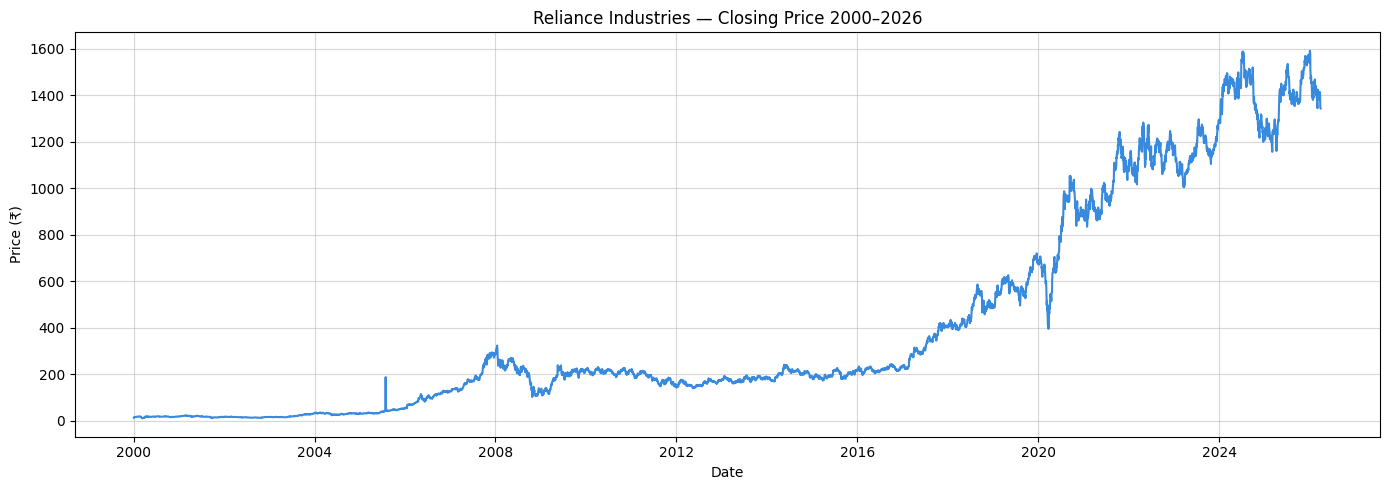

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['close'], color='#378ADD', linewidth=1.5)
plt.title('Reliance Industries — Closing Price 2000–2026')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
#Spiltting data fot prophet

In [11]:
prophet_data = df[["date","close"]].rename(columns= {"date":"ds","close":"y"})
prophet_train = prophet_data[prophet_data["ds"]<="2024-01-01"]
prophet_test = prophet_data[prophet_data["ds"] > "2024-01-01"]

In [12]:
#Make the model -->PROPHET

In [13]:
import sys
!{sys.executable} -m pip install prophet --quiet
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [15]:
model_pro = Prophet()
model_pro.fit(prophet_train)
future = model_pro.make_future_dataframe(periods = len(prophet_data) + 30 , freq = "B")
forecast = model_pro.predict(future)
forecast_test = forecast[forecast["ds"].isin(prophet_test["ds"])]
result = prophet_test[["ds","y"]].merge(forecast_test[["ds","yhat"]],left_on= "ds",right_on="ds")
result.head()

02:08:49 - cmdstanpy - INFO - Chain [1] start processing
02:08:53 - cmdstanpy - INFO - Chain [1] done processing


,ds,y,yhat
0,2024-01-02,1296.2559,1321.857475
1,2024-01-03,1282.1602,1322.235832
2,2024-01-04,1288.7860,1323.438104
3,2024-01-05,1294.2705,1322.934682
4,2024-01-08,1284.1704,1325.719389


In [16]:
import numpy as np
from sklearn.metrics import *
import matplotlib.pyplot as plt
import seaborn as sns

RMSE_Prophet = np.sqrt(mean_squared_error(result["y"],result["yhat"]))
R2_Prophet = r2_score(result["y"],result["yhat"])

print(f"RMSE score : ₹{RMSE_Prophet}")
print(f"R2 score : {R2_Prophet}")

RMSE score : ₹162.25089107680745
R2 score : -1.7316007604801684


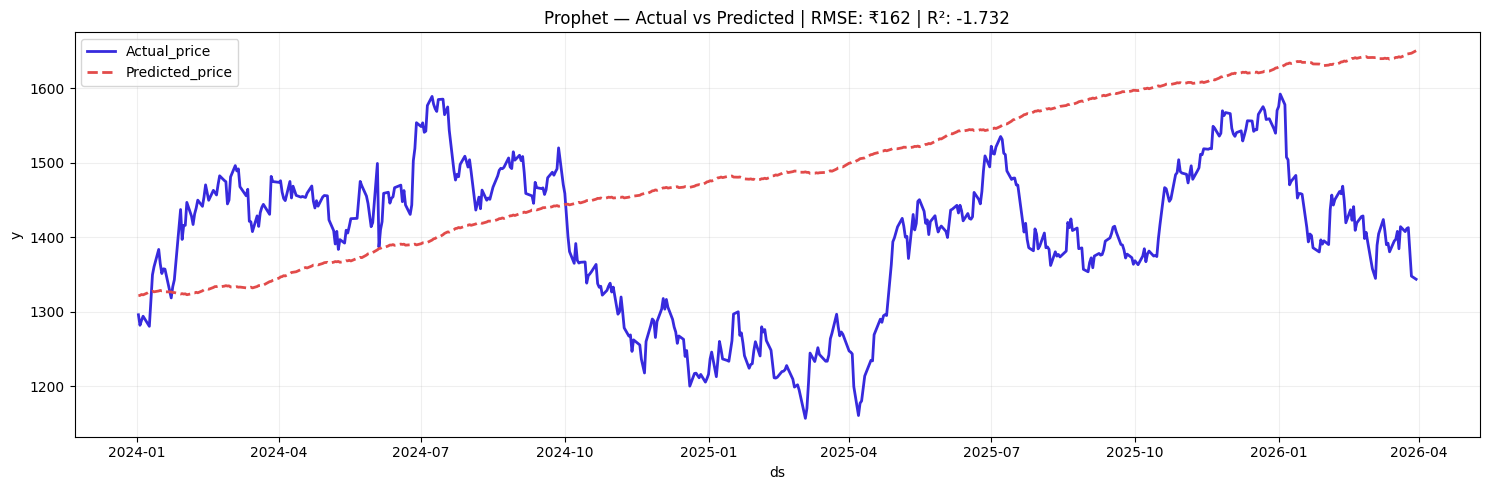

In [17]:
plt.figure(figsize=(15,5))
sns.lineplot(x=result["ds"],y=result["y"],label="Actual_price",color="#372ADD",linewidth=2)
sns.lineplot(x=result["ds"],y=result["yhat"],label="Predicted_price",color="#E24B4A",linewidth=2,linestyle="--")
plt.title(f'Prophet — Actual vs Predicted | RMSE: ₹{RMSE_Prophet:.0f} | R²: {R2_Prophet:.3f}')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout() 
plt.show()

In [18]:
#Make in the model using --> XGBOOST

In [19]:
#Feature engineering

In [20]:
#Make the copy of the original 

df_model = df[["date","close","volume"]].copy()
df_model = df_model.sort_values("date").reset_index(drop = True)
df_model.head()

,date,close,volume
0,2000-01-03,13.2444,62409578
1,2000-01-04,14.3047,132872110
2,2000-01-05,14.8651,375789847
3,2000-01-06,15.4886,219621124
4,2000-01-07,16.5516,278281260


In [21]:
#  1--> Adding past day changes
df_model["lag_1"] = df_model["close"].shift(1)
df_model["lag_5"] = df_model["close"].shift(5)
df_model["lag_10"] = df_model["close"].shift(10)
df_model["lag_21"] = df_model["close"].shift(21)

# 2 --> Moving avarage
df_model["ma_7"] = df_model["close"].rolling(7).mean()
df_model["ma_21"] = df_model["close"].rolling(21).mean()
df_model["ma_50"] = df_model["close"].rolling(50).mean()

# 3--> Market volatile
df_model["volatile"] = df_model["close"].rolling(14).std()

# 4--> pct changes
df_model["daily_return"] = df_model["close"].pct_change()
df_model["weakly_return"] = df_model["close"].pct_change(5)

# 5--> Momentum
delta = df["close"].diff()
gain = delta.clip(lower=0)
loss = (-delta).clip(lower=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = (avg_gain)/(avg_loss + 1e-9)
df_model["RSI"] = 100 - (100/(1 + rs))

# 6 --> price vs average moving price --> >1 up-trend , <1 down-trend
df_model["price vs ma_7"] = df_model["close"]/(df_model["ma_7"] + 1e-9)
df_model["price vs ma_21"] = df_model["close"]/(df_model["ma_7"] + 1e-9)
df_model["price vs ma_50"] = df_model["close"]/(df_model["ma_7"] + 1e-9)

# 7 --> volume
df_model['volume_MA7']   = df_model['volume'].rolling(7).mean()
df_model['volume_ratio'] = df_model['volume'] / (df_model['volume_MA7'] + 1)

# 8 --> target column
df_model['target'] = df_model['close'].shift(-1)

# 9--> remove NaN rows
df_model = df_model.dropna().reset_index(drop=True)

print(f"Rows: {len(df_model)}, Features: {df_model.shape[1]-3}")
print(df_model.head(5))

Rows: 6495, Features: 17
        date    close     volume    lag_1    lag_5   lag_10   lag_21  \
0 2000-03-10  11.4106   92389443  12.1710  14.1258  17.2909  18.7195   
1 2000-03-13  10.6923  150763063  11.4106  13.3628  17.5277  19.1168   
2 2000-03-14  11.5343  141532996  10.6923  12.7498  16.3569  18.5274   
3 2000-03-15  12.4577   79982280  11.5343  12.2578  16.6700  18.1196   
4 2000-03-16  12.3578  147946692  12.4577  12.1710  15.3518  18.3196   

        ma_7      ma_21      ma_50  volatile  daily_return  weakly_return  \
0  13.061371  16.250376  16.552666  2.364813     -0.062476      -0.192216   
1  12.395729  15.849210  16.501624  2.527449     -0.062950      -0.199846   
2  12.025514  15.516205  16.446216  2.526350      0.078748      -0.095335   
3  11.896214  15.246590  16.398068  2.352709      0.080057       0.016308   
4  11.840214  14.962695  16.335452  2.159925     -0.008019       0.015348   

         RSI  price vs ma_7  price vs ma_21  price vs ma_50    volume_MA7  \
0 

In [22]:
train = df_model[df_model['date'] <= '2024-12-31']
test  = df_model[df_model['date'] >  '2024-12-31']


# Define features — all columns except date, close (raw), target
FEATURES = [col for col in df_model.columns
            if col not in ['date', 'close', 'target']]
TARGET = 'target'
print(f"\nFeatures used ({len(FEATURES)}): {FEATURES}")

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

# ── TRAIN XGBOOST ─────────────────────────────────────────────
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators     = 1000,  
    learning_rate    = 0.03,  
    max_depth        = 5,      
    subsample        = 0.8,
    colsample_bytree = 0.8,
    early_stopping_rounds = 50, 
    random_state     = 42,
    verbosity        = 0
)

model_xgb.fit(
    X_train, y_train,
    eval_set  = [(X_test, y_test)],
    verbose   = False
)

# ── EVALUATE ──────────────────────────────────────────────────
y_pred = model_xgb.predict(X_test)

RMSE_XGB = np.sqrt(mean_squared_error(y_test, y_pred))
R2_XGB   = r2_score(y_test, y_pred)
MAE_XGB = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100

print(f"\nXGBoost Results:")
print(f"  RMSE : ₹{RMSE_XGB:.2f}  (avg prediction error)")
print(f"  R²   : {R2_XGB:.4f}    (1.0 = perfect)")
print(f"  MAPE : {MAE_XGB:.2f}%   (average % error)")


Features used (17): ['volume', 'lag_1', 'lag_5', 'lag_10', 'lag_21', 'ma_7', 'ma_21', 'ma_50', 'volatile', 'daily_return', 'weakly_return', 'RSI', 'price vs ma_7', 'price vs ma_21', 'price vs ma_50', 'volume_MA7', 'volume_ratio']

XGBoost Results:
  RMSE : ₹25.93  (avg prediction error)
  R²   : 0.9374    (1.0 = perfect)
  MAPE : 1.44%   (average % error)


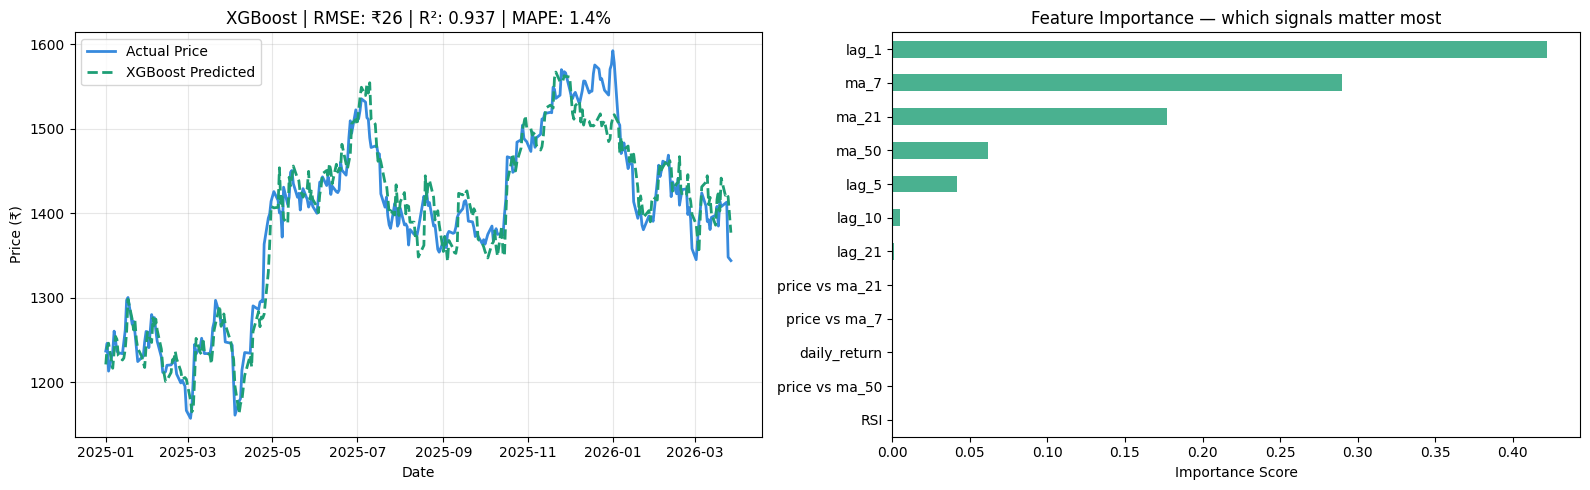

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 — actual vs predicted
axes[0].plot(test['date'].values, y_test.values,
             label='Actual Price',      color='#378ADD', linewidth=2)
axes[0].plot(test['date'].values, y_pred,
             label='XGBoost Predicted', color='#1D9E75',
             linewidth=2, linestyle='--')
axes[0].set_title(f'XGBoost | RMSE: ₹{RMSE_XGB:.0f} | R²: {R2_XGB:.3f} | MAPE: {MAE_XGB:.1f}%')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price (₹)')
axes[0].legend()
axes[0].grid(alpha=0.3)

feat_imp = pd.Series(
    model_xgb.feature_importances_,
    index=FEATURES
).sort_values(ascending=True).tail(12)   # top 12 features

feat_imp.plot(kind='barh', ax=axes[1], color='#1D9E75', alpha=0.8)
axes[1].set_title('Feature Importance — which signals matter most')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [25]:
# Remove unnecessary feature and re-train on xgbooost

In [58]:
fea_imp = pd.Series(
    model_xgb.feature_importances_,
    index = FEATURES
).sort_values(ascending= False)

print("\nAll feature list with their importance leval")
print(f"\n {(fea_imp.round(4)*100)} ")

thresold = 0.0001 # Remove which have < 0.1% importance

good_feature = fea_imp[fea_imp >= thresold].index.tolist()
bad_feature = fea_imp[fea_imp < thresold].index.tolist()

print(f"Good feature that we take in next model bulding : {good_feature} \n Total feature that we take = {len(good_feature)}")
print(f"bad feature that we not take in next model bulding : {bad_feature} \n Total feature that we not take = {len(bad_feature)}")


All feature list with their importance leval

 lag_1             42.230000
ma_7              28.960001
ma_21             17.720001
ma_50              6.190000
lag_5              4.160000
lag_10             0.490000
lag_21             0.120000
price vs ma_21     0.020000
price vs ma_7      0.020000
daily_return       0.020000
price vs ma_50     0.020000
RSI                0.010000
weakly_return      0.010000
volume_MA7         0.010000
volume_ratio       0.010000
volatile           0.000000
volume             0.000000
dtype: float32 
Good feature that we take in next model bulding : ['lag_1', 'ma_7', 'ma_21', 'ma_50', 'lag_5', 'lag_10', 'lag_21', 'price vs ma_21', 'price vs ma_7', 'daily_return', 'price vs ma_50', 'RSI'] 
 Total feature that we take = 12
bad feature that we not take in next model bulding : ['weakly_return', 'volume_MA7', 'volume_ratio', 'volatile', 'volume'] 
 Total feature that we not take = 5


In [61]:
x_train_slim = train[good_feature]
x_test_slim = test[good_feature]

model_slim = XGBRegressor(
    n_estimators     = 1000,
    learning_rate    = 0.03,
    max_depth        = 5,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    early_stopping_rounds = 50,
    random_state     = 42,
    verbosity        = 0
)
model_slim.fit(x_train_slim, y_train,
               eval_set=[(x_test_slim, y_test)], verbose=False)
y_pred_slim = model_slim.predict(x_test_slim)

RMSE_slim = np.sqrt(mean_squared_error(y_test, y_pred_slim))
R2_slim   = r2_score(y_test, y_pred_slim)
MAE_slim = np.mean(np.abs((y_test.values - y_pred_slim) / y_test.values)) * 100

print(f"\n── Before vs After dropping low-importance features ──")
print(f"{'Metric':<10} {'Before':>10} {'After':>10} {'Better?':>10}")
print("-"*42)
print(f"{'RMSE':<10} {'₹'+str(round(RMSE_XGB)):>10} {'₹'+str(round(RMSE_slim)):>10} {('✓' if RMSE_slim < RMSE_XGB else '✗'):>10}")
print(f"{'R²':<10} {round(R2_XGB,4):>10} {round(R2_slim,4):>10} {('✓' if R2_slim > R2_XGB else '✗'):>10}")
print(f"{'MAPE':<10} {str(round(MAE_XGB,2))+'%':>10} {str(round(MAE_slim,2))+'%':>10} {('✓' if MAE_slim < MAE_XGB else '✗'):>10}")


── Before vs After dropping low-importance features ──
Metric         Before      After    Better?
------------------------------------------
RMSE              ₹26        ₹25          ✓
R²             0.9374     0.9414          ✓
MAPE            1.44%      1.38%          ✓


In [62]:
#Hyperperameter tuning

In [65]:
import sys
!{sys.executable} -m pip install optuna --quiet
print("✓ Optuna installed")

✓ Optuna installed


In [71]:
import optuna
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

tscv = TimeSeriesSplit(n_splits=5)
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 3, 8),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0, 2),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0.1, 5),
        'random_state'     : 42,
        'verbosity'        : 0
    }
    model = XGBRegressor(**params)
    scores = cross_val_score(
        model, x_train_slim, y_train,
        cv      = tscv,
        scoring = 'neg_root_mean_squared_error',
        n_jobs  = -1
    )
    return -scores.mean()

study = optuna.create_study(direction='minimize')  # minimise RMSE
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✓ Optuna finished!")
print(f"Best CV RMSE: ₹{study.best_value:.2f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k:<22}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


✓ Optuna finished!
Best CV RMSE: ₹124.14
Best params:
  n_estimators          : 1157
  learning_rate         : 0.03846130667806185
  max_depth             : 4
  subsample             : 0.5244674296671766
  colsample_bytree      : 0.7453588775509
  min_child_weight      : 5
  gamma                 : 0.09058968522845923
  reg_alpha             : 0.039850327799568264
  reg_lambda            : 0.37138436720515466


In [74]:
# Use the best params Optuna found — train on your actual split
best_params = study.best_params
best_params['random_state'] = 42
best_params['verbosity']    = 0

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model_tuned = XGBRegressor(**best_params)
model_tuned.fit(x_train_slim, y_train)

y_pred_tuned = model_tuned.predict(x_test_slim)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned   = r2_score(y_test, y_pred_tuned)
mape_tuned = np.mean(np.abs((y_test.values - y_pred_tuned) / y_test.values)) * 100

print(f"Tuned XGBoost on actual test set:")
print(f"  RMSE : ₹{rmse_tuned:.2f}")
print(f"  R²   : {r2_tuned:.4f}")
print(f"  MAPE : {mape_tuned:.2f}%")

# Compare with original
print(f"\nOriginal XGBoost: RMSE=₹{RMSE_XGB:.2f}, R²={R2_XGB:.4f}")
winner = "Tuned" if rmse_tuned < RMSE_XGB else "Original"
print(f"Better model: {winner}")

Tuned XGBoost on actual test set:
  RMSE : ₹24.32
  R²   : 0.9450
  MAPE : 1.37%

Original XGBoost: RMSE=₹25.93, R²=0.9374
Better model: Tuned
